# The Colour Economy
## Does Pantone Create Shareholder Value for Colour-Aligned Brands?

**Author:** Khushali Gupta  

### Overview
This study applies financial event-study methodology to Pantone's annual 
Colour of the Year announcement, testing whether publicly listed companies 
whose brand identity is permanently anchored in that colour generate 
measurable abnormal stock returns relative to the S&P 500 in the 
6 months following each announcement.

**Time period:** 2020–2025  
**Sample:** 25 permanent colour-identity brands + 5 activation cases  
**Sectors:** FMCG, Tech, Consumer, Industrial, Logistics, Beauty, Retail, Telecom  
**Tools:** Python, pandas, yfinance, pytrends, matplotlib, scipy

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
print("All libraries loaded successfully")

All libraries loaded successfully


## Section 1 — Setup
Import all required libraries for data collection, analysis and visualisation.

In [2]:
import pandas as pd
#Load your master data file
df = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands - data.csv')
# See the first few rows
print(df.shape)
df.head(10)

(29, 9)


,year,colour_name,hex,announced_date,tier,brand,ticker,sector,colour_match
0,2020,Classic Blue,#0F4C81,2019-12-01,permanent,IBM,IBM,tech,primary
1,2020,Classic Blue,#0F4C81,2019-12-01,permanent,Meta,META,tech,primary
2,2020,Classic Blue,#0F4C81,2019-12-01,permanent,Pepsi,PEP,fmcg,primary
3,2020,Classic Blue,#0F4C81,2019-12-01,permanent,Ford,F,industrial,primary
4,2021,Ultimate Gray,#939597,2020-12-01,permanent,Apple,AAPL,tech,primary
5,2021,Ultimate Gray,#939598,2020-12-01,permanent,Mercedes-Benz,MBG.DE,industrial,primary
6,2021,Illuminating,#F5DF4D,2020-12-01,permanent,3M,MMM,fmcg,primary
7,2021,Illuminating,#F5DF4D,2020-12-01,permanent,Caterpillar,CAT,industrial,primary
8,2021,Ultimate Gray + Illuminating,both,2020-12-01,permanent,Best Buy,BBY,consumer,both
9,2022,Very Peri,#6667AB,2021-12-01,permanent,FedEx,FDX,logistics,primary


## Section 2 — Data Loading
Load the master brand dataset containing 30 brands across 6 Pantone 
colour years. Dataset includes permanent colour-identity brands (Tier 1) 
and active adoption cases (Tier 2).

In [3]:
# Show count by tier
print(df['tier'].value_counts())
#Show COunt by year and tier together
print(df.groupby(['year', 'tier'])['brand'].count())

tier
permanent     25
activation     4
Name: count, dtype: int64
year  tier      
2020  activation    1
      permanent     4
2021  permanent     5
2022  permanent     4
2023  activation    2
      permanent     4
2024  permanent     4
2025  activation    1
      permanent     4
Name: brand, dtype: int64


In [4]:
# Pull stock price data for all tickers in your dataset
import yfinance as yf
#Get unique tickers
tickers = df['ticker'].unique().tolist()
print("Tickers to pull: ")
print(tickers)
print(f"\nTotal tickers: {len(tickers)}")

Tickers to pull: 
['IBM', 'META', 'PEP', 'F', 'AAPL', 'MBG.DE', 'MMM', 'CAT', 'BBY', 'FDX', 'MDLZ', 'ZM', 'ETSY', 'TMUS', 'MA', 'ADBE', 'NFLX', 'EL', 'TPR', 'ULTA', 'CHD', 'UPS', 'NSRGY', 'HSY', 'LEVI', 'MSI']

Total tickers: 26


In [5]:
df = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands-data.csv')
df['announced_date'] = pd.to_datetime(df['announced_date'])
print("Master data loaded")
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands-data.csv'

In [ ]:
## Section 3 — Stock Price Data
Download historical daily closing prices for all 26 tickers via Yahoo Finance.
Date range: June 2019 to June 2025 — starting 6 months before the first 
announcement to establish baseline return patterns.
S&P 500 (^GSPC) downloaded separately as the market benchmark.

In [ ]:
# Define our full date range
start_date = '2019-6-01'
end_date = '2025-06-01'

#Download stock prices for all tickers at once
raw_prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

print('Download complete')
print(f"Shape: {raw_prices.shape}")
raw_prices.head()

NameError: name 'tickers' is not defined

In [ ]:

# Reload the fixed CSV
df = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands - data.csv')

# Confirm the fix
print(df[df['brand'].isin(['Pepsi', 'Ford'])][['brand', 'ticker']])

Data reloaded
    brand ticker
2   Pepsi    PEP
3    Ford      F
29   Ford      F


In [ ]:
#Get Unique tickers
tickers = df['ticker'].unique().tolist()

#Download stock prices for all tickers at once
raw_prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

print('Download complete')
print(f"Shape: {raw_prices.shape}")
raw_prices.head()

[*********************100%***********************]  26 of 26 completed

Download complete
Shape: (1549, 130)


Price           Close                                                \
Ticker           AAPL        ADBE        BBY         CAT        CHD   
Date                                                                  
2019-06-03  41.453739  259.029999  47.969612  104.418411  69.876053   
2019-06-04  42.970299  268.709991  48.515926  105.656044  69.085045   
2019-06-05  43.663971  272.859985  47.969612  106.556122  70.841835   
2019-06-06  44.305035  274.799988  47.271549  106.789795  71.577652   
2019-06-07  45.484299  278.160004  48.348995  107.715836  71.724838   

Price                                                                ...  \
Ticker              EL       ETSY         F         FDX         HSY  ...   
Date                                                                 ...   
2019-06-03  150.564453  61.070000  6.790113  134.156296  112.223671  ...   
2019-06-04  155.233246  61.250000  7.009149  140.540878  112.902107  ...   
2019-06-05  155.921158  61.490002  6.910228  139.660309  115.344505  ...   
2019-06-06  159.535019  61.959999  6.889033  138.127975  116.387657  ...   
2019-06-07  162.222549  63.889999  6.896098  139.158325  117.040649  ...   

Price          Volume                                                         \
Ticker            MMM        MSI        NFLX     NSRGY        PEP       TMUS   
Date                                                                           
2019-06-03  4456894.0  1351400.0  78496000.0  443400.0  3588700.0  2941000.0   
2019-06-04  4481173.0  1536600.0  78916000.0  317700.0  4242400.0  3144700.0   
2019-06-05  3781274.0  1447800.0  50201000.0  200200.0  5084200.0  1970200.0   
2019-06-06  4283833.0   863900.0  37100000.0  222600.0  5528000.0  2671000.0   
2019-06-07  2413169.0   637200.0  47773000.0  353200.0  6332700.0  2256600.0   

Price                                                   
Ticker            TPR       ULTA        UPS         ZM  
Date                                                    
2019-06-03  4469700.0  1023700.0  4971400.0  1570500.0  
2019-06-04  4840600.0   773500.0  5096000.0  1134900.0  
2019-06-05  5328200.0   577200.0  2766900.0  1295800.0  
2019-06-06  3323500.0   590700.0  2643200.0  3024000.0  
2019-06-07  3215000.0   567300.0  2803200.0  9487800.0  

[5 rows x 130 columns]

In [ ]:
# Download S&P 500 as arket benchmark
sp500 = yf.download (
    '^GSPC',
    start=start_date,
    end=end_date,
    auto_adjust=True
    )
print("S&P 500 downloaded")
print(f'Shape: {sp500.shape}')
sp500.head()

[*********************100%***********************]  1 of 1 completed

S&P 500 downloaded
Shape: (1508, 5)


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2019-06-03,2744.449951,2763.070068,2728.810059,2751.530029,3952360000
2019-06-04,2803.270020,2804.489990,2762.639893,2762.639893,3814130000
2019-06-05,2826.149902,2827.280029,2800.919922,2818.090088,3570760000
2019-06-06,2843.489990,2852.100098,2822.449951,2828.510010,3445140000
2019-06-07,2873.340088,2884.969971,2852.870117,2852.870117,3244380000


In [ ]:
# Save raw data so we don't need to re-download
raw_prices.to_csv('/Users/khushaligupta/Desktop/colour-economy/data/raw_prices.csv')
sp500.to_csv('/Users/khushaligupta/Desktop/colour-economy/data/sp500.csv')

print("Data saved successfully")

Data saved successfully


## Section 4 — Return Calculations
Calculate daily percentage returns for all stocks and the S&P 500.
Abnormal returns = each stock's daily return minus the S&P 500 return 
on the same day. Measures daily outperformance or underperformance 
relative to the broad market.

In [ ]:
#Extract only the Close prices for all stocks 
close_prices = raw_prices['Close']

#Calculate daily returns for all stocks
stock_returns = close_prices.pct_change()

#Calculate daily returns for S&P 500
sp500_returns = sp500['Close'].pct_change()

#Remove the first row which will be NaN
# (no return can be calculated for the very frist day)
stock_returns = stock_returns.dropna(how='all')
sp500_returns = sp500_returns.dropna()

print("Returns calculated")
print(f"Stock returns shape:{ stock_returns.shape}")
print(f"S&P 500 returns shape: {sp500_returns.shape}")
stock_returns.head

Returns calculated
Stock returns shape:(1548, 26)
S&P 500 returns shape: (1507, 1)


<bound method NDFrame.head of Ticker          AAPL      ADBE       BBY       CAT       CHD        EL  \
Date                                                                     
2019-06-04  0.036584  0.037370  0.011389  0.011853 -0.011320  0.031009   
2019-06-05  0.016143  0.015444 -0.011261  0.008519  0.025429  0.004431   
2019-06-06  0.014682  0.007110 -0.014552  0.002193  0.010387  0.023177   
2019-06-07  0.026617  0.012227  0.022793  0.008672  0.002056  0.016846   
2019-06-10  0.012779  0.007837  0.023070  0.010285 -0.008849  0.006559   
...              ...       ...       ...       ...       ...       ...   
2025-05-26       NaN       NaN       NaN       NaN       NaN       NaN   
2025-05-27       NaN       NaN       NaN       NaN       NaN       NaN   
2025-05-28  0.001049 -0.002106 -0.009693 -0.005747  0.000715 -0.011781   
2025-05-29 -0.002345  0.002741 -0.072707  0.006581  0.001837  0.036216   
2025-05-30  0.004501  0.004185 -0.000603 -0.010688  0.001732 -0.020199   

Ticker 

In [ ]:
# Align Stock Returns and S&P 500 returns on the same dates
# Some dates exist in onr but not the other due to different exchanges
sp500_aligned = sp500_returns.reindex(stock_returns.index)

# Rename S&P 500 column for clarity
sp500_aligned.columns = ['sp500_returns']

#Calculate abnormal returns for every stock every day
# Subtract market return from each stock's return
abnormal_returns = stock_returns.sub(sp500_aligned['sp500_returns'], axis=0)

print("Abnormal returns calculated")
print(f"Shape: {abnormal_returns.shape}")
abnormal_returns.head()

Abnormal returns calculated
Shape: (1548, 26)


Ticker,AAPL,ADBE,BBY,CAT,CHD,EL,ETSY,F,FDX,HSY,...,MMM,MSI,NFLX,NSRGY,PEP,TMUS,TPR,ULTA,UPS,ZM
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-04,0.015152,0.015938,-0.010044,-0.009580,-0.032753,0.009576,-0.018485,0.010826,0.026158,-0.015387,...,0.005124,0.010456,0.028385,-0.036829,-0.020735,-0.001351,0.021246,-0.006520,0.016069,0.015985
2019-06-05,0.007981,0.007282,-0.019422,0.000357,0.017268,-0.003730,-0.004243,-0.022275,-0.014427,0.013471,...,-0.010840,0.015350,-0.001569,-0.002684,0.009813,-0.000235,-0.004169,-0.002350,-0.002530,-0.017052
2019-06-06,0.008546,0.000974,-0.020688,-0.003943,0.004251,0.017042,0.001508,-0.009203,-0.017107,0.002908,...,-0.000826,-0.003957,-0.002200,-0.001480,0.005709,-0.010592,-0.013577,0.002309,-0.008274,0.011676
2019-06-07,0.016119,0.001729,0.012295,-0.001826,-0.008441,0.006348,0.020651,-0.009472,-0.003038,-0.004887,...,0.000976,0.005653,-0.000025,-0.000243,0.000792,0.003722,0.011116,-0.016874,-0.008151,0.173564
2019-06-10,0.008119,0.003177,0.018410,0.005625,-0.013509,0.001899,0.017566,0.001488,0.019514,-0.013862,...,0.005423,-0.017315,-0.029212,-0.007393,-0.003761,-0.009333,-0.013916,-0.007943,0.014275,0.079869


In [ ]:
# Save abnormal returns
abnormal_returns.to_csv('/Users/khushaligupta/Desktop/colour-economy/data/abnormal_returns.csv')
stock_returns.to_csv('/Users/khushaligupta/Desktop/colour-economy/data/stock_returns.csv')

print("Saved successfully")

Saved successfully


## Section 5 — Cumulative Abnormal Returns (CAR)
Sum abnormal returns over a 6-month window (180 days) following each 
Pantone announcement for Tier 1 permanent brands.
One CAR value per brand per year — the total accumulated 
outperformance or underperformance over the measurement window.

In [ ]:
import pandas as pd

# Make sure announced_date is treated as a date
df['announced_date'] = pd.to_datetime(df['announced_date'])

# Define window length
months_6 = 180

# Store results here
car_results = []

# Loop through each brand in your dataset
for _, row in df[df['tier'] == 'permanent'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    announcement = row['announced_date']
    
    # Define the window
    window_start = announcement
    window_end = announcement + pd.DateOffset(days=180)
    
    # Get abnormal returns for this stock in this window
    if ticker not in abnormal_returns.columns:
        continue
        
    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    
    # Calculate CAR
    car = stock_ar.sum()
    
    # Store result
    car_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'sector': sector,
        'car': car,
        'observations': len(stock_ar)
    })

# Convert to dataframe
car_df = pd.DataFrame(car_results)
print(f"CAR calculated for {len(car_df)} brands")
car_df

NameError: name 'df' is not defined

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded")

Libraries loaded


In [ ]:
df = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands - data.csv')
df['announced_date'] = pd.to_datetime(df['announced_date'])
print("Master data loaded")
print(df.shape)

Master data loaded
(30, 9)


In [ ]:
raw_prices = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/raw_prices.csv', 
                         header=[0,1], 
                         index_col=0, 
                         parse_dates=True)

sp500 = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/sp500.csv',
                    header=[0,1],
                    index_col=0,
                    parse_dates=True)

print("Price data loaded")
print(f"Stock prices shape: {raw_prices.shape}")
print(f"S&P 500 shape: {sp500.shape}")

Price data loaded
Stock prices shape: (1549, 130)
S&P 500 shape: (1508, 5)


In [ ]:
close_prices = raw_prices['Close']
stock_returns = close_prices.pct_change().dropna(how='all')

sp500_returns = sp500['Close'].pct_change().dropna()
sp500_aligned = sp500_returns.reindex(stock_returns.index)
sp500_aligned.columns = ['sp500_return']

abnormal_returns = stock_returns.sub(sp500_aligned['sp500_return'], axis=0)

print("Returns and abnormal returns calculated")
print(f"Abnormal returns shape: {abnormal_returns.shape}")

Returns and abnormal returns calculated
Abnormal returns shape: (1548, 26)


In [ ]:
import pandas as pd

# Make sure announced_date is treated as a date
df['announced_date'] = pd.to_datetime(df['announced_date'])

# Define window length
months_6 = 180

# Store results here
car_results = []

# Loop through each brand in your dataset
for _, row in df[df['tier'] == 'permanent'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    announcement = row['announced_date']
    
    # Define the window
    window_start = announcement
    window_end = announcement + pd.DateOffset(days=180)
    
    # Get abnormal returns for this stock in this window
    if ticker not in abnormal_returns.columns:
        continue
        
    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    
    # Calculate CAR
    car = stock_ar.sum()
    
    # Store result
    car_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'sector': sector,
        'car': car,
        'observations': len(stock_ar)
    })

# Convert to dataframe
car_df = pd.DataFrame(car_results)
print(f"CAR calculated for {len(car_df)} brands")
car_df

CAR calculated for 25 brands


,year,colour,brand,ticker,sector,car,observations
0,2020,Classic Blue,IBM,IBM,tech,-0.038815,127
1,2020,Classic Blue,Meta,META,tech,0.158301,127
2,2020,Classic Blue,Pepsi,PEP,fmcg,0.039696,127
3,2020,Classic Blue,Ford,F,industrial,-0.385542,127
4,2021,Ultimate Gray,Apple,AAPL,tech,-0.065608,126
5,2021,Ultimate Gray,Mercedes-Benz,MBG.DE,industrial,0.204457,126
6,2021,Illuminating,3M,MMM,fmcg,0.030670,126
7,2021,Illuminating,Caterpillar,CAT,industrial,0.183656,126
8,2021,Ultimate Gray + Illuminating,Best Buy,BBY,consumer,-0.025009,126
9,2022,Very Peri,FedEx,FDX,logistics,0.071941,127


In [ ]:
df = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/pantone_brands - data.csv')
df['announced_date'] = pd.to_datetime(df['announced_date'])
print("Master data reloaded")
print(df[df['year'] == 2024][['year', 'colour_name', 'brand', 'ticker']])

Master data reloaded
    year colour_name            brand ticker
17  2024  Peach fuzz     Estee Lauder     EL
18  2024  Peach fuzz         Tapestry    TPR
19  2024  Peach fuzz      Ulta Beauty   ULTA
20  2024  Peach fuzz  Church & Dwight    CHD


In [ ]:
raw_prices = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/raw_prices.csv', 
                         header=[0,1], 
                         index_col=0, 
                         parse_dates=True)

sp500 = pd.read_csv('/Users/khushaligupta/Desktop/colour-economy/data/sp500.csv',
                    header=[0,1],
                    index_col=0,
                    parse_dates=True)

print("Price data loaded")

Price data loaded


In [ ]:
close_prices = raw_prices['Close']
stock_returns = close_prices.pct_change().dropna(how='all')

sp500_returns = sp500['Close'].pct_change().dropna()
sp500_aligned = sp500_returns.reindex(stock_returns.index)
sp500_aligned.columns = ['sp500_return']

abnormal_returns = stock_returns.sub(sp500_aligned['sp500_return'], axis=0)

print("Returns calculated")

Returns calculated


In [ ]:
car_results = []

for _, row in df[df['tier'] == 'permanent'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    announcement = row['announced_date']
    
    window_start = announcement
    window_end = announcement + pd.DateOffset(days=180)
    
    if ticker not in abnormal_returns.columns:
        continue
        
    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    car = stock_ar.sum()
    
    car_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'sector': sector,
        'car': car,
        'observations': len(stock_ar)
    })

car_df = pd.DataFrame(car_results)
print(f"CAR calculated for {len(car_df)} brands")
car_df

CAR calculated for 25 brands


,year,colour,brand,ticker,sector,car,observations
0,2020,Classic Blue,IBM,IBM,tech,-0.038815,127
1,2020,Classic Blue,Meta,META,tech,0.158301,127
2,2020,Classic Blue,Pepsi,PEP,fmcg,0.039696,127
3,2020,Classic Blue,Ford,F,industrial,-0.385542,127
4,2021,Ultimate Gray,Apple,AAPL,tech,-0.065608,126
5,2021,Ultimate Gray,Mercedes-Benz,MBG.DE,industrial,0.204457,126
6,2021,Illuminating,3M,MMM,fmcg,0.030670,126
7,2021,Illuminating,Caterpillar,CAT,industrial,0.183656,126
8,2021,Ultimate Gray + Illuminating,Best Buy,BBY,consumer,-0.025009,126
9,2022,Very Peri,FedEx,FDX,logistics,0.071941,127


In [ ]:
#Average CAR per colour year
yearly_summary = car_df.groupby(['year', 'colour'])['car'].agg(['mean', 'min', 'max','count']).reset_index()
yearly_summary.columns = ['year','colour','avg_car','worst_car','best_car','num_brands']
yearly_summary['avg_car_pct'] = (yearly_summary['avg_car']*100).round(2)
yearly_summary['worst_car_pct'] = (yearly_summary['worst_car']*100).round(2)
yearly_summary['best_car_pct'] = (yearly_summary['best_car']*100).round(2)

print("=== AVERAGE CAR BY COLOUR Year ===")
print(yearly_summary[['year','colour','avg_car_pct','worst_car_pct','best_car_pct','num_brands']].to_string())

=== AVERAGE CAR BY COLOUR Year ===
   year                        colour  avg_car_pct  worst_car_pct  best_car_pct  num_brands
0  2020                  Classic Blue        -5.66         -38.55         15.83           4
1  2021                  Illuminating        10.72           3.07         18.37           2
2  2021                Ultimate Gray          6.94          -6.56         20.45           2
3  2021  Ultimate Gray + Illuminating        -2.50          -2.50         -2.50           1
4  2022                     Very Peri       -29.51         -93.33         15.69           4
5  2023                  Viva Magenta         7.82         -12.69         24.23           4
6  2024                    Peach fuzz        -6.54         -24.70         15.60           4
7  2025                  Mocha Mousse         3.87         -27.15         29.15           4


In [ ]:
# Save CAR results
car_df.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/car_results.csv', index=False)
yearly_summary.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/yearly_summary.csv', index=False)

print("Results saved to output folder")

Results saved to output folder


## Section 6 — Statistical Testing
Run one-sample t-tests to determine whether CAR values are 
statistically significantly different from zero.
A p-value below 0.05 indicates the result is unlikely to be random noise.
H1: Colour-aligned brands generate abnormal returns significantly 
different from zero.

In [ ]:
from scipy import stats
import numpy as np

print("=== T-TEST RESULTS ===\n")

#Test 1 - Are Overall CARs signifiacntly different from zero?
all_cars = car_df['car'].values
t_stat, p_value = stats.ttest_1samp(all_cars, popmean=0)

print("OVERALL: Are colour-aligned brands different from market?")
print(f"Average CAR: {np.mean(all_cars)*100:2f}%")
print(f"T-stastic: {t_stat: .3f}")
print(f"P-Value: {p_value: .3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")
print("\n--- BY COLOUR YEAR ---\n")

#Test 2 - T- test for each colour year seperately
for year in car_df['year'].unique():
    year_cars = car_df[car_df['year'] == year]['car'].values
    if len(year_cars) < 2:
        print(f"{year}: Not enough data points")
        continue
    t_stat, p_value = stats.ttest_1samp(year_cars, popmean=0)
    avg = np.mean(year_cars)*100

    print(f"{year}:")
    print(f" Average CAR: {avg: .2f}%")
    print(f" P-value: {p_value: .3f}")
    print(f" Significant: {'YES' if p_value < 0.05 else 'NO'}\n")

=== T-TEST RESULTS ===

OVERALL: Are colour-aligned brands different from market?
Average CAR: -3.489139%
T-stastic: -0.643
P-Value:  0.526
Significant: NO

--- BY COLOUR YEAR ---

2020:
 Average CAR: -5.66%
 P-value:  0.661
 Significant: NO

2021:
 Average CAR:  6.56%
 P-value:  0.296
 Significant: NO

2022:
 Average CAR: -29.51%
 P-value:  0.331
 Significant: NO

2023:
 Average CAR:  7.82%
 P-value:  0.417
 Significant: NO

2024:
 Average CAR: -6.54%
 P-value:  0.491
 Significant: NO

2025:
 Average CAR:  3.87%
 P-value:  0.782
 Significant: NO



In [ ]:
# Save t-test summary
ttest_results = []

for year in car_df['year'].unique():
    year_cars = car_df[car_df['year'] == year]['car'].values
    if len(year_cars) < 2:
        continue
    t_stat, p_value = stats.ttest_1samp(year_cars, popmean=0)
    ttest_results.append({
        'year': year,
        'avg_car_pct': round(np.mean(year_cars) * 100, 2),
        't_stat': round(t_stat, 3),
        'p_value': round(p_value, 3),
        'significant': 'YES' if p_value < 0.05 else 'NO'
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/ttest_results.csv', index=False)
print("T-test results saved")
print(ttest_df)

T-test results saved
   year  avg_car_pct  t_stat  p_value significant
0  2020        -5.66  -0.484    0.661          NO
1  2021         6.56   1.200    0.296          NO
2  2022       -29.51  -1.158    0.331          NO
3  2023         7.82   0.940    0.417          NO
4  2024        -6.54  -0.783    0.491          NO
5  2025         3.87   0.303    0.782          NO


## Section 7 — Cultural Momentum Analysis
Pull Google Trends search volume for each Pantone colour in the 
3 months following announcement.
Test whether cultural buzz around a colour predicts the size of 
abnormal returns for colour-aligned brands.
H2: Higher search interest predicts larger CAR.

In [ ]:
from pytrends.request import TrendReq
import time

# Initialize pytrends
pytrends = TrendReq(hl='en-US', tz=360)

# Your colour search terms matched to each year
colour_terms = {
    2020: 'Classic Blue',
    2021: 'Pantone 2021',
    2022: 'Very Peri',
    2023: 'Viva Magenta',
    2024: 'Peach Fuzz',
    2025: 'Mocha Mousse'
}

# Store results
trends_results = []

for year, term in colour_terms.items():
    print(f"Pulling trends for {year}: {term}")
    
    # Define timeframe - 3 months after announcement
    # Announcement is December 1, so we pull Dec-Feb
    timeframe = f'{year-1}-12-01 {year}-03-01'
    
    try:
        # Build payload - this sets up your search
        pytrends.build_payload(
            [term],
            cat=0,
            timeframe=timeframe,
            geo='',
            gprop=''
        )
        
        # Pull interest over time
        data = pytrends.interest_over_time()
        
        if not data.empty:
            avg_interest = data[term].mean()
            max_interest = data[term].max()
            
            trends_results.append({
                'year': year,
                'colour_term': term,
                'avg_interest': round(avg_interest, 2),
                'max_interest': round(max_interest, 2)
            })
            print(f"  Average interest: {avg_interest:.2f}")
        
        # Wait 2 seconds between requests to avoid rate limiting
        time.sleep(2)
        
    except Exception as e:
        print(f"  Error for {year}: {e}")

trends_df = pd.DataFrame(trends_results)
print("\nTrends data complete")
print(trends_df)

Pulling trends for 2020: Classic Blue
  Average interest: 32.32
Pulling trends for 2021: Pantone 2021
  Average interest: 23.95
Pulling trends for 2022: Very Peri
  Average interest: 14.25
Pulling trends for 2023: Viva Magenta
  Average interest: 14.14
Pulling trends for 2024: Peach Fuzz
  Average interest: 17.35
Pulling trends for 2025: Mocha Mousse
  Average interest: 16.33

Trends data complete
   year   colour_term  avg_interest  max_interest
0  2020  Classic Blue         32.32           100
1  2021  Pantone 2021         23.95           100
2  2022     Very Peri         14.25           100
3  2023  Viva Magenta         14.14           100
4  2024    Peach Fuzz         17.35           100
5  2025  Mocha Mousse         16.33           100


In [ ]:
# Merge trends with yearly summary
merged_df = yearly_summary.merge(trends_df, on='year', how='left')

# Drop duplicate colour year rows for 2021
# Keep only the combined summary rows
merged_df = merged_df.dropna(subset=['avg_interest'])

print("=== TRENDS + CAR MERGED ===")
print(merged_df[['year', 'colour', 'avg_car_pct', 'avg_interest', 'num_brands']].to_string())

=== TRENDS + CAR MERGED ===
   year                        colour  avg_car_pct  avg_interest  num_brands
0  2020                  Classic Blue        -5.66         32.32           4
1  2021                  Illuminating        10.72         23.95           2
2  2021                Ultimate Gray          6.94         23.95           2
3  2021  Ultimate Gray + Illuminating        -2.50         23.95           1
4  2022                     Very Peri       -29.51         14.25           4
5  2023                  Viva Magenta         7.82         14.14           4
6  2024                    Peach fuzz        -6.54         17.35           4
7  2025                  Mocha Mousse         3.87         16.33           4


In [ ]:
# Collapse to one row per year for correlation analysis
yearly_correlation = merged_df.groupby(['year', 'avg_interest']).agg(
    avg_car_pct=('avg_car_pct', 'mean')
).reset_index()

print("=== ONE ROW PER YEAR ===")
print(yearly_correlation.to_string())

# Now test the correlation between search interest and CAR
correlation, p_value = stats.pearsonr(
    yearly_correlation['avg_interest'],
    yearly_correlation['avg_car_pct']
)

print(f"\n=== CORRELATION: SEARCH INTEREST vs CAR ===")
print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

=== ONE ROW PER YEAR ===
   year  avg_interest  avg_car_pct
0  2020         32.32    -5.660000
1  2021         23.95     5.053333
2  2022         14.25   -29.510000
3  2023         14.14     7.820000
4  2024         17.35    -6.540000
5  2025         16.33     3.870000

=== CORRELATION: SEARCH INTEREST vs CAR ===
Correlation coefficient: 0.143
P-value: 0.786
Significant: NO


In [ ]:
yearly_correlation.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/trends_car_correlation.csv', index=False)
merged_df.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/merged_summary.csv', index=False)

print("Saved successfully")

Saved successfully


In [ ]:
# Tier 2 - Activation Analysis
activation_results = []

for _, row in df[df['tier'] == 'activation'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    activation_date = row['announced_date']
    
    # 90 day window for activation
    window_start = activation_date
    window_end = activation_date + pd.DateOffset(days=90)
    
    if ticker not in abnormal_returns.columns:
        print(f"Ticker {ticker} not found - skipping")
        continue
    
    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    car = stock_ar.sum()
    
    activation_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'activation_date': activation_date,
        'car_90day': round(car, 4),
        'car_90day_pct': round(car * 100, 2),
        'observations': len(stock_ar)
    })

activation_df = pd.DataFrame(activation_results)
print(f"Activation analysis complete for {len(activation_df)} cases")
print(activation_df[['year', 'colour', 'brand', 'car_90day_pct', 'observations']].to_string())

Activation analysis complete for 5 cases
   year        colour               brand  car_90day_pct  observations
0  2023  Viva Magenta  Motorola Solutions          -0.65            64
1  2023  Viva Magenta        Levi Strauss          13.04            64
2  2023  Viva Magenta  Motorola Solutions          -0.65            64
3  2025  Mocha Mousse  Motorola Solutions          -7.43            63
4  2020  Classic Blue                Ford         -18.47            63


In [ ]:
# Save activation results
activation_df = activation_df.drop_duplicates(subset=['year', 'colour', 'brand'])
activation_df.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/activation_results.csv', index=False)

print("Activation results saved")
print(activation_df[['year', 'colour', 'brand', 'car_90day_pct', 'observations']].to_string())

Activation results saved
   year        colour               brand  car_90day_pct  observations
0  2023  Viva Magenta  Motorola Solutions          -0.65            64
1  2023  Viva Magenta        Levi Strauss          13.04            64
3  2025  Mocha Mousse  Motorola Solutions          -7.43            63
4  2020  Classic Blue                Ford         -18.47            63


## Section 8 — Additional Analysis
Four supplementary angles tested:
1. Sector performance — which industries benefit most from colour alignment?
2. Warm vs cool colours — does colour temperature predict returns?
3. Heritage vs consumer brands — does brand type moderate the effect?
4. Winner vs loser gap — is performance divergence growing over time?

In [ ]:
import numpy as np

print("=" * 50)
print("ANGLE 1: SECTOR PERFORMANCE")
print("=" * 50)

sector_summary = car_df.groupby('sector')['car'].agg(['mean', 'count']).reset_index()
sector_summary.columns = ['sector', 'avg_car', 'num_brands']
sector_summary['avg_car_pct'] = (sector_summary['avg_car'] * 100).round(2)
sector_summary = sector_summary.sort_values('avg_car_pct', ascending=False)
print(sector_summary[['sector', 'avg_car_pct', 'num_brands']].to_string())

print("\n" + "=" * 50)
print("ANGLE 2: WARM VS COOL COLOURS")
print("=" * 50)

warm_colours = ['Viva Magenta', 'Peach fuzz', 'Mocha Mousse', 'Illuminating']
cool_colours = ['Classic Blue', 'Very Peri', 'Ultimate Gray', 
                'Ultimate Gray + Illuminating']

car_df['colour_temp'] = car_df['colour'].apply(
    lambda x: 'warm' if x in warm_colours else 'cool'
)

temp_summary = car_df.groupby('colour_temp')['car'].agg(['mean', 'count']).reset_index()
temp_summary.columns = ['colour_temp', 'avg_car', 'num_brands']
temp_summary['avg_car_pct'] = (temp_summary['avg_car'] * 100).round(2)
print(temp_summary.to_string())

# T-test warm vs cool
warm_cars = car_df[car_df['colour_temp'] == 'warm']['car'].values
cool_cars = car_df[car_df['colour_temp'] == 'cool']['car'].values
t_stat, p_value = stats.ttest_ind(warm_cars, cool_cars)
print(f"\nWarm vs Cool T-test:")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

print("\n" + "=" * 50)
print("ANGLE 3: HERITAGE VS CONSUMER BRANDS")
print("=" * 50)

heritage_sectors = ['industrial', 'logistics', 'fmcg']
consumer_sectors = ['tech', 'consumer', 'beauty', 'retail', 'telecom']

car_df['brand_tier'] = car_df['sector'].apply(
    lambda x: 'heritage' if x in heritage_sectors else 'consumer_facing'
)

tier_summary = car_df.groupby('brand_tier')['car'].agg(['mean', 'count']).reset_index()
tier_summary.columns = ['brand_tier', 'avg_car', 'num_brands']
tier_summary['avg_car_pct'] = (tier_summary['avg_car'] * 100).round(2)
print(tier_summary.to_string())

# T-test heritage vs consumer
heritage_cars = car_df[car_df['brand_tier'] == 'heritage']['car'].values
consumer_cars = car_df[car_df['brand_tier'] == 'consumer_facing']['car'].values
t_stat, p_value = stats.ttest_ind(heritage_cars, consumer_cars)
print(f"\nHeritage vs Consumer T-test:")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

print("\n" + "=" * 50)
print("ANGLE 4: WINNER VS LOSER GAP OVER TIME")
print("=" * 50)

gap_summary = car_df.groupby('year')['car'].agg(
    lambda x: (x.max() - x.min()) * 100
).reset_index()
gap_summary.columns = ['year', 'gap_pct']
gap_summary['gap_pct'] = gap_summary['gap_pct'].round(2)
print(gap_summary.to_string())

correlation_gap, p_gap = stats.pearsonr(
    gap_summary['year'],
    gap_summary['gap_pct']
)
print(f"\nGap widening over time:")
print(f"Correlation: {correlation_gap:.3f}")
print(f"P-value: {p_gap:.3f}")
print(f"Significant: {'YES' if p_gap < 0.05 else 'NO'}")

ANGLE 1: SECTOR PERFORMANCE
       sector  avg_car_pct  num_brands
2        fmcg         6.53           6
3  industrial         0.09           3
6        tech         0.01           6
4   logistics        -9.98           2
0      beauty       -10.73           1
1    consumer       -11.73           5
7     telecom       -12.69           1
5      retail       -24.70           1

ANGLE 2: WARM VS COOL COLOURS
  colour_temp   avg_car  num_brands  avg_car_pct
0        cool -0.082961          13        -8.30
1        warm  0.017184          12         1.72

Warm vs Cool T-test:
P-value: 0.367
Significant: NO

ANGLE 3: HERITAGE VS CONSUMER BRANDS
        brand_tier   avg_car  num_brands  avg_car_pct
0  consumer_facing -0.076217          14        -7.62
1         heritage  0.017705          11         1.77

Heritage vs Consumer T-test:
P-value: 0.402
Significant: NO

ANGLE 4: WINNER VS LOSER GAP OVER TIME
   year  gap_pct
0  2020    54.38
1  2021    27.01
2  2022   109.02
3  2023    36.91
4  2

## Section 9 — Tier 2 Activation Analysis
Test whether brands that actively launched products in the Pantone colour 
show a distinct short-term stock price effect.
Window: 90 days (3 months) following the product activation date.
H3: Active colour adoption generates returns independent of 
permanent colour identity.

In [ ]:
print("ANGLE 3 FULL OUTPUT")
print(tier_summary.to_string())
print(f"\nHeritage avg CAR: {heritage_cars.mean()*100:.2f}%")
print(f"Consumer avg CAR: {consumer_cars.mean()*100:.2f}%")

# Also run sector t-test FMCG vs everyone else
fmcg_cars = car_df[car_df['sector'] == 'fmcg']['car'].values
non_fmcg_cars = car_df[car_df['sector'] != 'fmcg']['car'].values
t_stat, p_value = stats.ttest_ind(fmcg_cars, non_fmcg_cars)
print(f"\nFMCG vs Non-FMCG T-test:")
print(f"FMCG avg CAR: {fmcg_cars.mean()*100:.2f}%")
print(f"Non-FMCG avg CAR: {non_fmcg_cars.mean()*100:.2f}%")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

ANGLE 3 FULL OUTPUT
        brand_tier   avg_car  num_brands  avg_car_pct
0  consumer_facing -0.076217          14        -7.62
1         heritage  0.017705          11         1.77

Heritage avg CAR: 1.77%
Consumer avg CAR: -7.62%

FMCG vs Non-FMCG T-test:
FMCG avg CAR: 6.53%
Non-FMCG avg CAR: -6.65%
P-value: 0.309
Significant: NO


In [ ]:
# Save sector and additional analysis
sector_summary.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/sector_analysis.csv', index=False)
car_df.to_csv('/Users/khushaligupta/Desktop/colour-economy/output/car_results_full.csv', index=False)

print("Additional analysis saved")

Additional analysis saved


## Section 10 — Visualisations
Four charts summarising the complete analysis:
1. Average CAR by Pantone colour year
2. Individual brand performance across all years
3. Google Trends search interest vs average CAR
4. Sector performance comparison

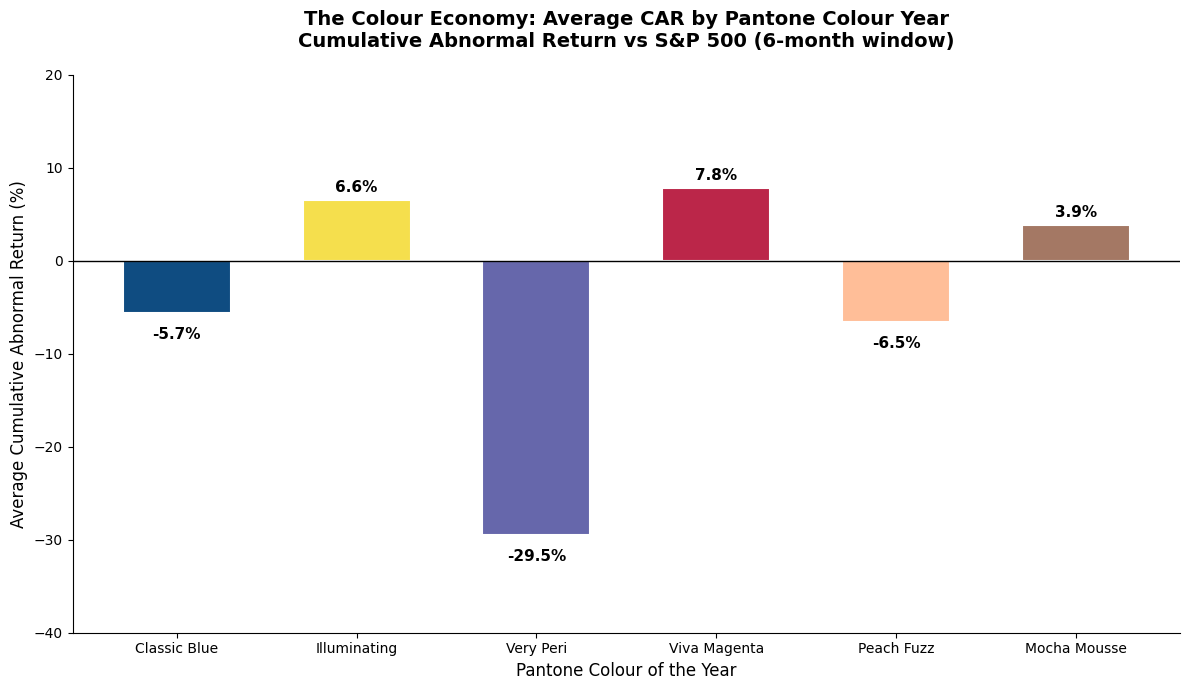

Chart 1 saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Actual Pantone hex colours for each year
pantone_colours = {
    2020: '#0F4C81',  # Classic Blue
    2021: '#F5DF4D',  # Illuminating (using warm yellow for 2021)
    2022: '#6667AB',  # Very Peri
    2023: '#BB2649',  # Viva Magenta
    2024: '#FFBE98',  # Peach Fuzz
    2025: '#A47864'   # Mocha Mousse
}

# Collapse to one row per year
chart1_data = car_df.groupby('year')['car'].mean().reset_index()
chart1_data['car_pct'] = chart1_data['car'] * 100
chart1_data['colour'] = chart1_data['year'].map(pantone_colours)

# Colour labels
colour_labels = {
    2020: 'Classic Blue',
    2021: 'Illuminating',
    2022: 'Very Peri',
    2023: 'Viva Magenta',
    2024: 'Peach Fuzz',
    2025: 'Mocha Mousse'
}
chart1_data['label'] = chart1_data['year'].map(colour_labels)

# Build chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    chart1_data['label'],
    chart1_data['car_pct'],
    color=chart1_data['colour'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Add zero line
ax.axhline(y=0, color='black', linewidth=1, linestyle='-')

# Add value labels on bars
for bar, val in zip(bars, chart1_data['car_pct']):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        f'{val:.1f}%',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=11,
        fontweight='bold'
    )

# Styling
ax.set_title(
    'The Colour Economy: Average CAR by Pantone Colour Year\n'
    'Cumulative Abnormal Return vs S&P 500 (6-month window)',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Pantone Colour of the Year', fontsize=12)
ax.set_ylabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylim(-40, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/khushaligupta/Desktop/colour-economy/output/chart1_car_by_year.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

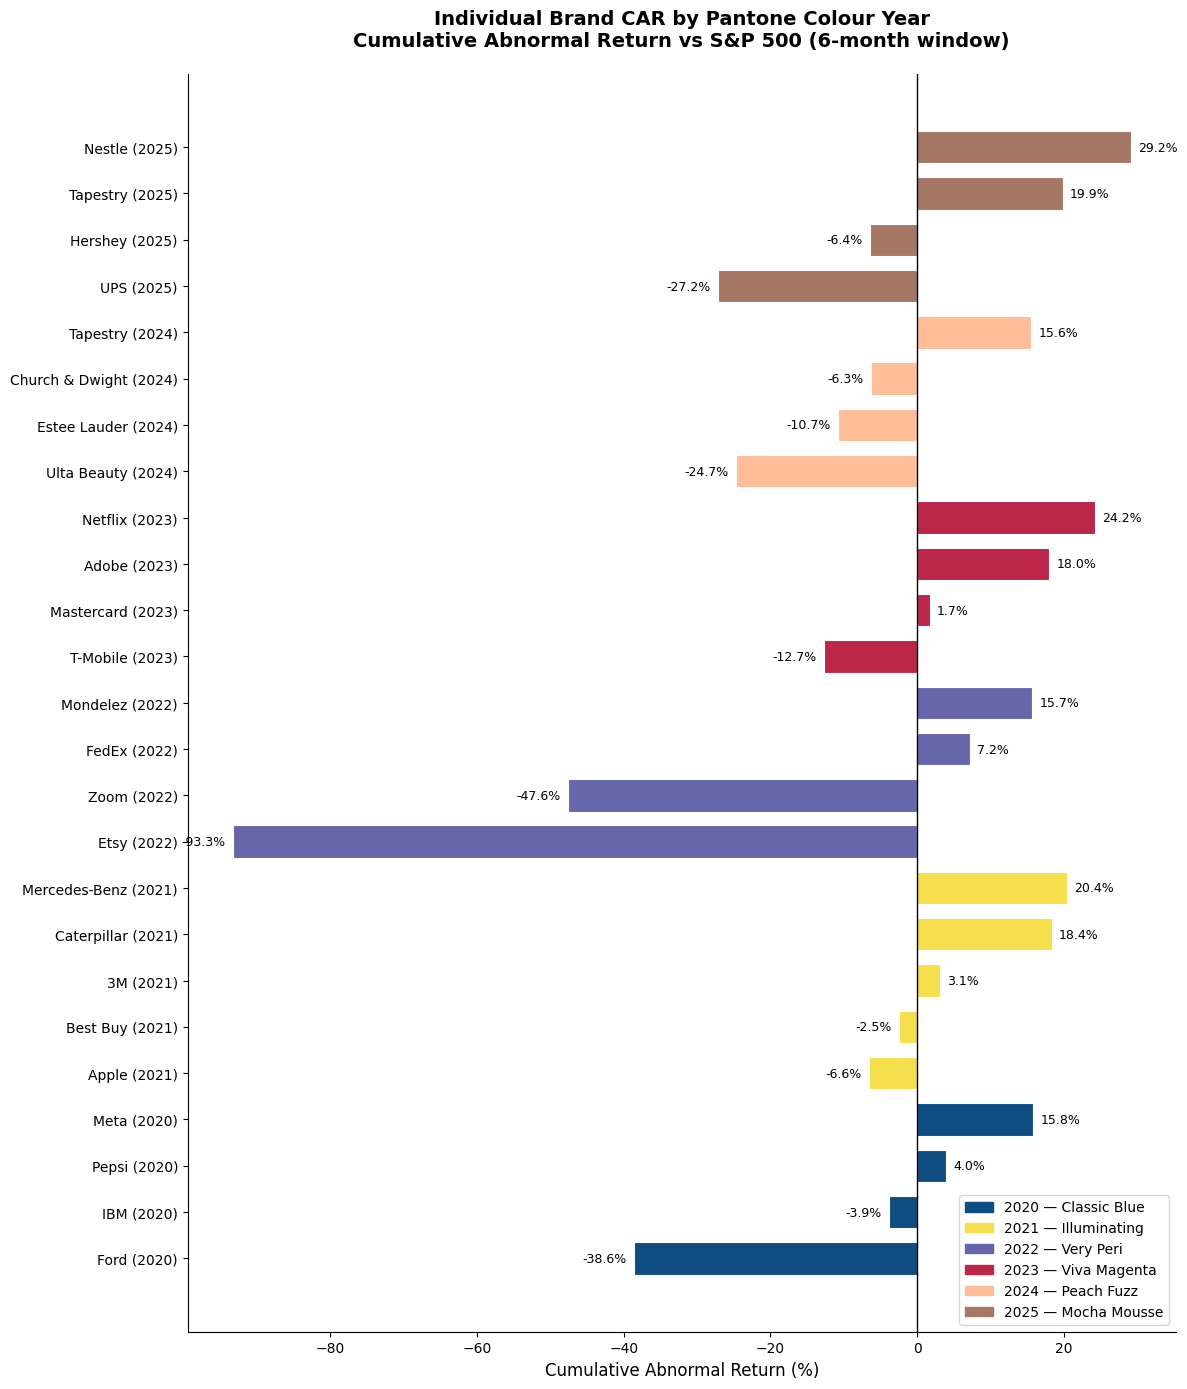

Chart 2 saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 14))

# Sort by year then CAR
chart2_data = car_df.sort_values(['year', 'car'], ascending=[True, True]).copy()
chart2_data['car_pct'] = chart2_data['car'] * 100
chart2_data['bar_colour'] = chart2_data['year'].map(pantone_colours)
chart2_data['bar_label'] = chart2_data['brand'] + ' (' + chart2_data['year'].astype(str) + ')'

# Draw horizontal bars
bars = ax.barh(
    chart2_data['bar_label'],
    chart2_data['car_pct'],
    color=chart2_data['bar_colour'],
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

# Zero line
ax.axvline(x=0, color='black', linewidth=1)

# Value labels
for bar, val in zip(bars, chart2_data['car_pct']):
    xpos = val + 1 if val >= 0 else val - 1
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        ha=ha,
        fontsize=9
    )

# Legend
legend_patches = [
    mpatches.Patch(color=pantone_colours[yr], label=f"{yr} — {colour_labels[yr]}")
    for yr in sorted(pantone_colours.keys())
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

# Styling
ax.set_title(
    'Individual Brand CAR by Pantone Colour Year\n'
    'Cumulative Abnormal Return vs S&P 500 (6-month window)',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '/Users/khushaligupta/Desktop/colour-economy/output/chart2_individual_brands.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 2 saved")

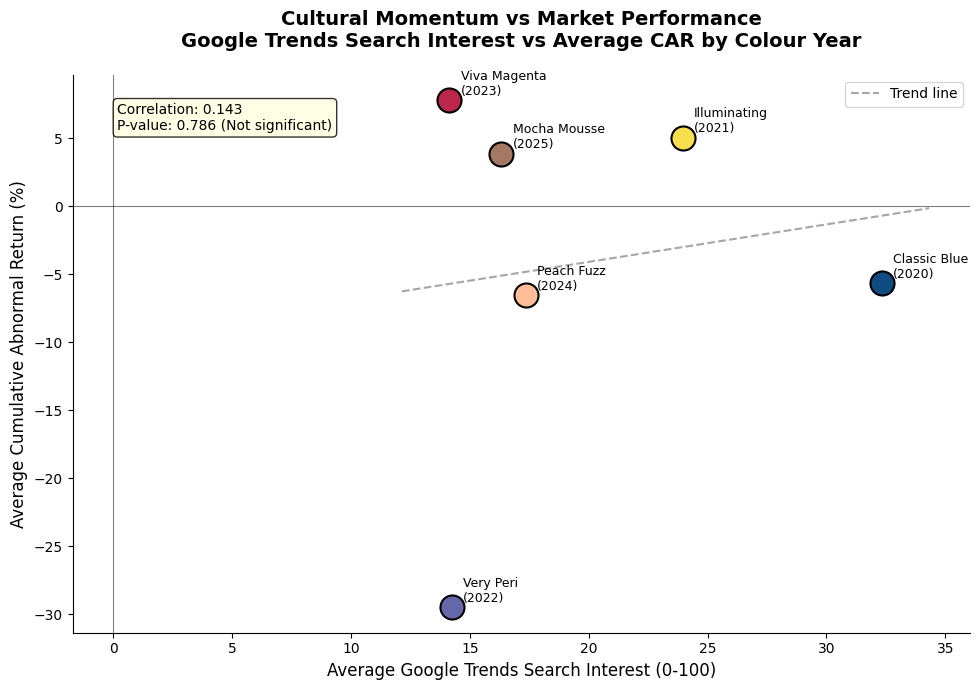

Chart 3 saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each year as a dot
for _, row in yearly_correlation.iterrows():
    year = int(row['year'])
    colour = pantone_colours[year]
    label = colour_labels[year]
    
    ax.scatter(
        row['avg_interest'],
        row['avg_car_pct'],
        color=colour,
        s=300,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )
    
    ax.annotate(
        f"{label}\n({year})",
        xy=(row['avg_interest'], row['avg_car_pct']),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=9
    )

# Add trend line
z = np.polyfit(yearly_correlation['avg_interest'], yearly_correlation['avg_car_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(yearly_correlation['avg_interest'].min() - 2,
                     yearly_correlation['avg_interest'].max() + 2, 100)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=1.5, alpha=0.7, label='Trend line')

# Zero lines
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)

# Correlation annotation
ax.text(
    0.05, 0.95,
    f'Correlation: 0.143\nP-value: 0.786 (Not significant)',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# Styling
ax.set_title(
    'Cultural Momentum vs Market Performance\n'
    'Google Trends Search Interest vs Average CAR by Colour Year',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Average Google Trends Search Interest (0-100)', fontsize=12)
ax.set_ylabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '/Users/khushaligupta/Desktop/colour-economy/output/chart3_trends_vs_car.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 3 saved")

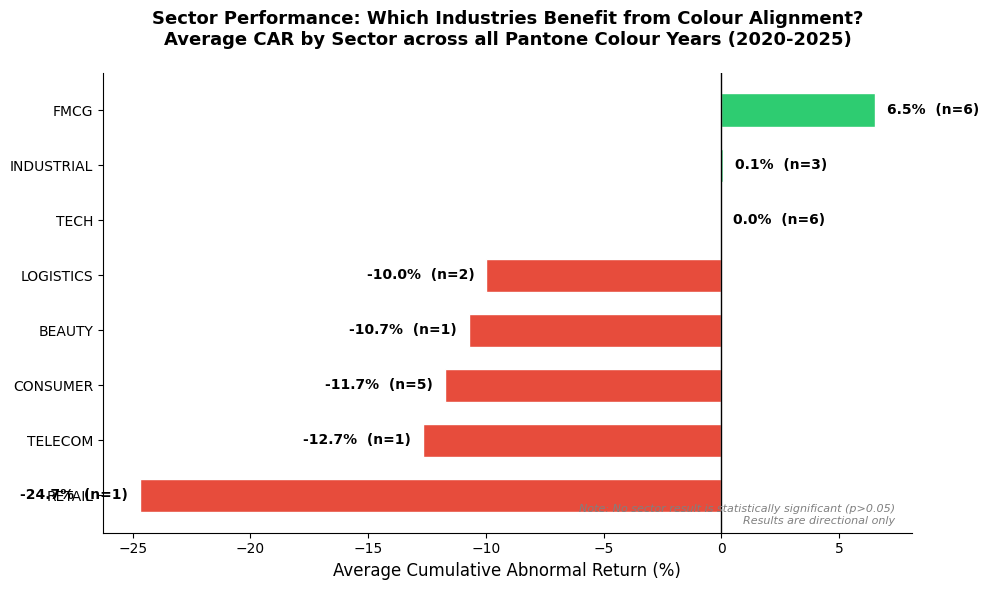

Chart 4 saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by avg CAR
chart4_data = sector_summary.sort_values('avg_car_pct', ascending=True)

# Colour bars green if positive, red if negative
bar_colours = ['#2ecc71' if x >= 0 else '#e74c3c' for x in chart4_data['avg_car_pct']]

bars = ax.barh(
    chart4_data['sector'].str.upper(),
    chart4_data['avg_car_pct'],
    color=bar_colours,
    edgecolor='white',
    linewidth=1,
    height=0.6
)

# Zero line
ax.axvline(x=0, color='black', linewidth=1)

# Value labels and sample size
for bar, val, n in zip(bars, chart4_data['avg_car_pct'], chart4_data['num_brands']):
    xpos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={n})',
        va='center',
        ha=ha,
        fontsize=10,
        fontweight='bold'
    )

# Styling
ax.set_title(
    'Sector Performance: Which Industries Benefit from Colour Alignment?\n'
    'Average CAR by Sector across all Pantone Colour Years (2020-2025)',
    fontsize=13,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add note about significance
ax.text(
    0.98, 0.02,
    'Note: No sector result is statistically significant (p>0.05)\nResults are directional only',
    transform=ax.transAxes,
    fontsize=8,
    ha='right',
    color='gray',
    style='italic'
)

plt.tight_layout()
plt.savefig(
    '/Users/khushaligupta/Desktop/colour-economy/output/chart4_sector_performance.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 4 saved")

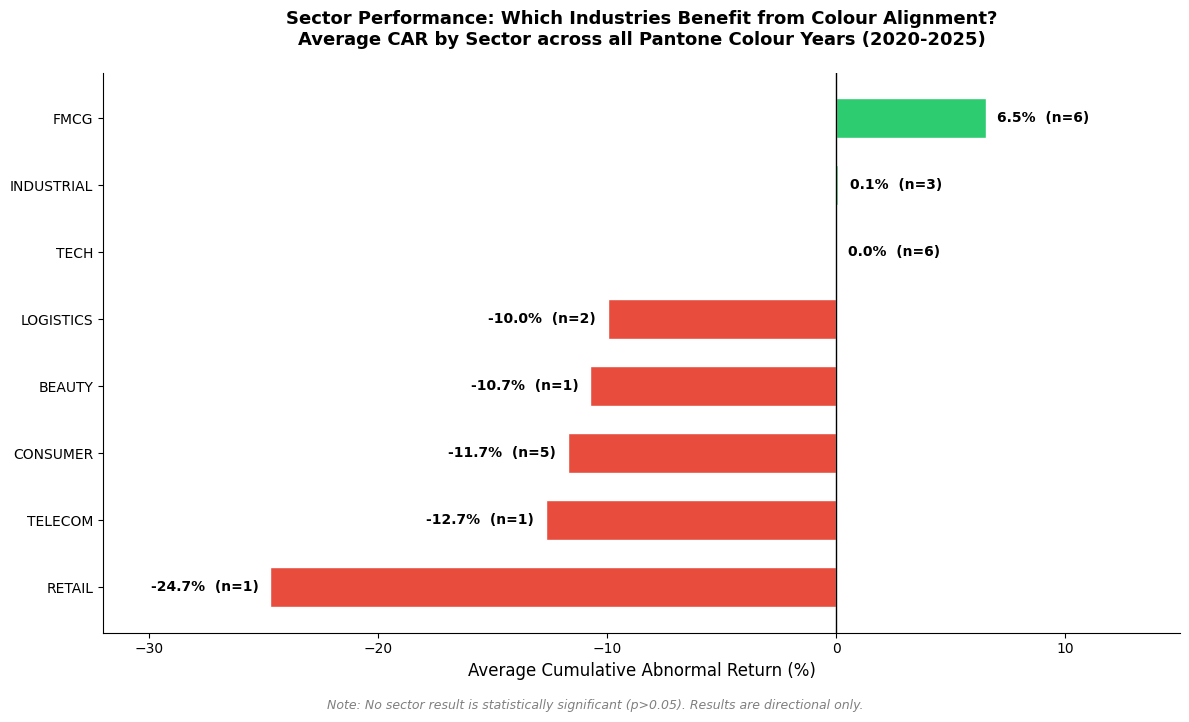

Chart 4 saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

chart4_data = sector_summary.sort_values('avg_car_pct', ascending=True)
bar_colours = ['#2ecc71' if x >= 0 else '#e74c3c' for x in chart4_data['avg_car_pct']]

bars = ax.barh(
    chart4_data['sector'].str.upper(),
    chart4_data['avg_car_pct'],
    color=bar_colours,
    edgecolor='white',
    linewidth=1,
    height=0.6
)

ax.axvline(x=0, color='black', linewidth=1)

for bar, val, n in zip(bars, chart4_data['avg_car_pct'], chart4_data['num_brands']):
    xpos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={n})',
        va='center',
        ha=ha,
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Sector Performance: Which Industries Benefit from Colour Alignment?\n'
    'Average CAR by Sector across all Pantone Colour Years (2020-2025)',
    fontsize=13,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylabel('')

# Fix x-axis to give room for retail label
ax.set_xlim(-32, 15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move note below chart
fig.text(
    0.5, -0.02,
    'Note: No sector result is statistically significant (p>0.05). Results are directional only.',
    ha='center',
    fontsize=9,
    color='gray',
    style='italic'
)

plt.tight_layout()
plt.savefig(
    '/Users/khushaligupta/Desktop/colour-economy/output/chart4_sector_performance.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 4 saved")

## Section 11 — Conclusions

### Key Findings

**H1 — Not supported**  
Average CAR: -3.49% | P-value: 0.526  
Colour alignment does not predict market outperformance.

**H2 — Not supported**  
Correlation: 0.143 | P-value: 0.786  
Cultural momentum does not predict abnormal returns.

**H3 — Inconclusive**  
4 activation cases. Levi's +13%, Motorola consistently flat or negative.  
Insufficient sample for statistical conclusion.

**Sector Finding (Directional)**  
FMCG: +6.5% | Consumer: -11.7% | Retail: -24.7%  
Sector moderates the colour effect more than the colour itself.

### Synthesis
Pantone's Colour of the Year is a cultural signal, not a financial one. 
Equity markets show no measurable response to colour alignment even in 
the most unambiguous cases. However, a consistent directional pattern 
suggests FMCG brands with permanent colour identities are better 
positioned to benefit from cultural colour moments than 
trend-sensitive consumer brands.

### Limitations
- Sample size (n=25) limits statistical power
- No control for macro confounders (COVID, interest rates, sector cycles)
- Google Trends is an imperfect proxy for cultural momentum
- Activation tier too small for statistical inference (n=4)

### Future Research
- Extend time series to 2000 (25 Pantone announcements)
- Expand brand universe to 50+ companies per sector
- Apply market model beta-adjustment for more rigorous CAR calculation
- Test against luxury-specific benchmark index